# Lab 6: archived notebook

This is the uploaded analysis with saved outputs retained. Local Windows file paths were replaced with paths relative to this notebook; a local output path in the saved log was shortened. Numerical code and cached figures are otherwise preserved.

**Authorship:** The accompanying report states the code was generated with ChatGPT 5.1 Extended Thinking. This is a record of AI-assisted laboratory analysis, not a claim of independently authored code.

**Calibration review:** The historical `alpha_MHz_per_ms = 33609` produces approximately 29 GHz linewidths. Its units/derivation have not been verified. Do not treat the cached MHz results as validated. See [analysis review](../ANALYSIS_REVIEW.md).

For the tested portable version, use [src/analyze.py](../src/analyze.py) and the project README. Running this archived notebook creates PNG files and a Word report in its working directory; it additionally needs pandas, python-docx and Jupyter.


Fitted background parameters: a = 1.0360, b = 0.0934 V


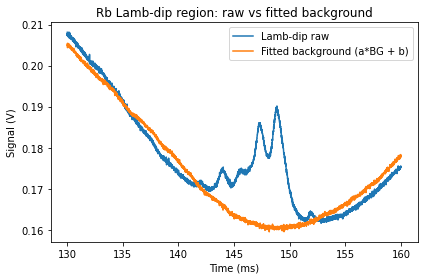

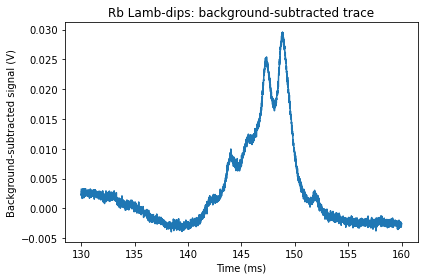

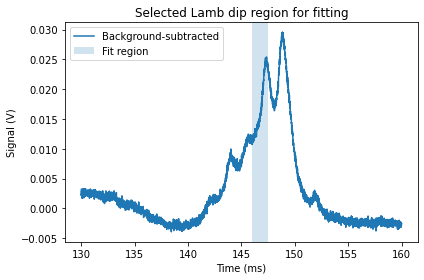


=== Gaussian fit ===
A = 1.2353e-02, t0 = 147.344 ms, FWHM = 0.8452 ms, C = 1.2311e-02
RSS (sum of squared residuals) = 6.1051e-05

=== Lorentzian fit ===
A = 1.4719e-02, t0 = 147.320 ms, FWHM = 0.8605 ms, C = 1.0287e-02
RSS (sum of squared residuals) = 3.6782e-05

Lorentzian gives the smaller RSS → better fit to this Lamb dip.

Gaussian linewidth ≈ 28407.43 MHz
Lorentzian linewidth ≈ 28920.65 MHz


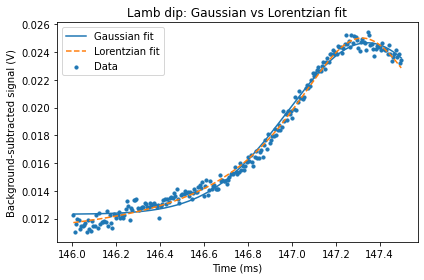

Saved Word report to: LambDip_Analysis_Report.docx


In [22]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
from docx import Document
from docx.shared import Inches

# -------------------------------------------------------
# 1) USER INPUTS
# -------------------------------------------------------
lamb_file = r"../data/measurements/doppler-broadened_20251112_171638_HighRes.csv"
bg_file = r"../data/measurements/doppler-broadened_20251112_172148_HighRes.csv"

signal_channel = "chA"   # "chA" or "chB" depending on where your photodiode is

# Time window (s) containing the Lamb-dip region
t_min, t_max = 0.130, 0.160    # 130–160 ms total window

# Rough guess of where the dips live (s) – excluded from background fit
dip_region_min = 0.145         # 145 ms
dip_region_max = 0.150         # 150 ms

# Region around ONE Lamb dip for fitting (ms)
fit_t_min_ms = 146.0           # tweak to the dip you want
fit_t_max_ms = 147.5

# Etalon calibration slope (MHz per ms)
alpha_MHz_per_ms = 33609       # your value
# -------------------------------------------------------


def load_moku_csv(path):
    """Load Moku CSV (3 cols: t, chA, chB) skipping first 10 metadata lines."""
    return pd.read_csv(path, skiprows=10, header=None,
                       names=["t", "chA", "chB"])


# -------------------------------------------------------
# 2) LOAD DATA + BACKGROUND SUBTRACTION
# -------------------------------------------------------
lamb = load_moku_csv(lamb_file)
bg   = load_moku_csv(bg_file)

# Crop to region of interest
lamb_reg = lamb[(lamb["t"] >= t_min) & (lamb["t"] <= t_max)].reset_index(drop=True)
bg_reg   = bg[(bg["t"]   >= t_min) & (bg["t"]   <= t_max)].reset_index(drop=True)

t    = lamb_reg["t"].values
t_ms = t * 1e3

sig_lamb = lamb_reg[signal_channel].values
sig_bg   = bg_reg[signal_channel].values

# Interpolate background onto Lamb time grid
bg_interp = interp1d(bg_reg["t"].values, sig_bg,
                     kind="linear", fill_value="extrapolate")
bg_on_lamb = bg_interp(t)

# Fit linear background: Lamb ≈ a * BG + b, excluding dip region
mask_nodip = ~((t >= dip_region_min) & (t <= dip_region_max))

X = np.vstack([bg_on_lamb[mask_nodip], np.ones(mask_nodip.sum())]).T
y = sig_lamb[mask_nodip]

a, b = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"Fitted background parameters: a = {a:.4f}, b = {b:.4f} V")

bg_fit = a * bg_on_lamb + b

# Background-subtracted signal
sig_sub = sig_lamb - bg_fit

# -------------------------------------------------------
# 3) PLOTS (AND SAVE THEM)
# -------------------------------------------------------

# (a) Raw Lamb trace vs fitted background
fig1, ax1 = plt.subplots()
ax1.plot(t_ms, sig_lamb, label="Lamb-dip raw")
ax1.plot(t_ms, bg_fit, label="Fitted background (a*BG + b)")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Signal (V)")
ax1.set_title("Rb Lamb-dip region: raw vs fitted background")
ax1.legend()
fig1.tight_layout()
fig1.savefig("raw_vs_background.png", dpi=300)

# (b) Background-subtracted Lamb-dip trace
fig2, ax2 = plt.subplots()
ax2.plot(t_ms, sig_sub)
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Background-subtracted signal (V)")
ax2.set_title("Rb Lamb-dips: background-subtracted trace")
fig2.tight_layout()
fig2.savefig("bgsub_full.png", dpi=300)

# -------------------------------------------------------
# 4) SELECT ONE LAMB DIP + FIT GAUSSIAN & LORENTZIAN
# -------------------------------------------------------
fit_mask = (t_ms >= fit_t_min_ms) & (t_ms <= fit_t_max_ms)
t_fit_ms = t_ms[fit_mask]
y_fit    = sig_sub[fit_mask]

# Quick sanity plot of the selected region (optional show)
plt.figure()
plt.plot(t_ms, sig_sub, label="Background-subtracted")
plt.axvspan(fit_t_min_ms, fit_t_max_ms, alpha=0.2, label="Fit region")
plt.xlabel("Time (ms)")
plt.ylabel("Signal (V)")
plt.title("Selected Lamb dip region for fitting")
plt.legend()
plt.tight_layout()
plt.show()

def gaussian(t, A, t0, w, C):
    """Gaussian with FWHM = w (ms)."""
    return A * np.exp(-4 * np.log(2) * ((t - t0) / w)**2) + C

def lorentzian(t, A, t0, w, C):
    """Lorentzian with FWHM = w (ms)."""
    return A / (1 + (2 * (t - t0) / w)**2) + C

# Initial guesses
A0  = y_fit.max() - y_fit.min()
t0_0 = t_fit_ms[np.argmax(y_fit)]
w0  = (t_fit_ms[-1] - t_fit_ms[0]) / 4.0
C0  = y_fit.min()
p0 = [A0, t0_0, w0, C0]

# Fit both models
popt_g, pcov_g = curve_fit(gaussian,   t_fit_ms, y_fit, p0=p0)
popt_l, pcov_l = curve_fit(lorentzian, t_fit_ms, y_fit, p0=p0)

A_g, t0_g, w_g, C_g = popt_g
A_l, t0_l, w_l, C_l = popt_l

# Residuals and RSS
res_g = y_fit - gaussian(t_fit_ms,   *popt_g)
res_l = y_fit - lorentzian(t_fit_ms, *popt_l)

rss_g = np.sum(res_g**2)
rss_l = np.sum(res_l**2)

print("\n=== Gaussian fit ===")
print(f"A = {A_g:.4e}, t0 = {t0_g:.3f} ms, FWHM = {w_g:.4f} ms, C = {C_g:.4e}")
print(f"RSS (sum of squared residuals) = {rss_g:.4e}")

print("\n=== Lorentzian fit ===")
print(f"A = {A_l:.4e}, t0 = {t0_l:.3f} ms, FWHM = {w_l:.4f} ms, C = {C_l:.4e}")
print(f"RSS (sum of squared residuals) = {rss_l:.4e}")

if rss_l < rss_g:
    print("\nLorentzian gives the smaller RSS → better fit to this Lamb dip.")
else:
    print("\nGaussian gives the smaller RSS → better fit to this Lamb dip.")

# Linewidths in MHz (if calibration known)
linewidth_gauss_MHz = None
linewidth_lor_MHz   = None
if alpha_MHz_per_ms != 0.0:
    linewidth_gauss_MHz = w_g * alpha_MHz_per_ms
    linewidth_lor_MHz   = w_l * alpha_MHz_per_ms
    print(f"\nGaussian linewidth ≈ {linewidth_gauss_MHz:.2f} MHz")
    print(f"Lorentzian linewidth ≈ {linewidth_lor_MHz:.2f} MHz")

# (c) Plot data + both fits and save
t_dense = np.linspace(t_fit_ms.min(), t_fit_ms.max(), 400)
y_gauss = gaussian(t_dense,   *popt_g)
y_lor   = lorentzian(t_dense, *popt_l)

fig3, ax3 = plt.subplots()
ax3.scatter(t_fit_ms, y_fit, s=10, label="Data")
ax3.plot(t_dense, y_gauss, label="Gaussian fit")
ax3.plot(t_dense, y_lor,   linestyle="--", label="Lorentzian fit")
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("Background-subtracted signal (V)")
ax3.set_title("Lamb dip: Gaussian vs Lorentzian fit")
ax3.legend()
fig3.tight_layout()
fig3.savefig("lamb_dip_fit.png", dpi=300)

plt.show()

# -------------------------------------------------------
# 5) SAVE EVERYTHING TO A WORD FILE
# -------------------------------------------------------

doc = Document()
doc.add_heading("Doppler-Free Spectroscopy – Lamb Dip Analysis", level=0)

# Basic info about the run
doc.add_paragraph(f"Lamb-dip trace file: {os.path.basename(lamb_file)}")
doc.add_paragraph(f"Background trace file: {os.path.basename(bg_file)}")

# ---- Fit parameter table ----
doc.add_heading("Single Lamb Dip Fits", level=1)

table = doc.add_table(rows=3, cols=6)
hdr = table.rows[0].cells
hdr[0].text = "Model"
hdr[1].text = "t₀ (ms)"
hdr[2].text = "FWHM (ms)"
hdr[3].text = "FWHM (MHz)"
hdr[4].text = "Amplitude (V)"
hdr[5].text = "RSS"

row_g = table.rows[1].cells
row_g[0].text = "Gaussian"
row_g[1].text = f"{t0_g:.3f}"
row_g[2].text = f"{w_g:.4f}"
row_g[3].text = (
    "—" if linewidth_gauss_MHz is None else f"{linewidth_gauss_MHz:.2f}"
)
row_g[4].text = f"{A_g:.3e}"
row_g[5].text = f"{rss_g:.3e}"

row_l = table.rows[2].cells
row_l[0].text = "Lorentzian"
row_l[1].text = f"{t0_l:.3f}"
row_l[2].text = f"{w_l:.4f}"
row_l[3].text = (
    "—" if linewidth_lor_MHz is None else f"{linewidth_lor_MHz:.2f}"
)
row_l[4].text = f"{A_l:.3e}"
row_l[5].text = f"{rss_l:.3e}"

better_model = "Lorentzian" if rss_l < rss_g else "Gaussian"
doc.add_paragraph(
    f"Based on the RSS values, the {better_model} model provides the better fit."
)

# ---- First few points of background-subtracted trace ----
doc.add_heading("Background-Subtracted Trace (first 10 points)", level=1)

n_show = min(10, len(t_ms))
trace_table = doc.add_table(rows=n_show + 1, cols=2)
hdr2 = trace_table.rows[0].cells
hdr2[0].text = "Time (ms)"
hdr2[1].text = "Signal (V)"

for i in range(n_show):
    row = trace_table.rows[i + 1].cells
    row[0].text = f"{t_ms[i]:.3f}"
    row[1].text = f"{sig_sub[i]:.4e}"

# ---- Add figures (assumes you already saved them) ----
doc.add_heading("Figures", level=1)

if os.path.exists("raw_vs_background.png"):
    doc.add_paragraph("Raw Lamb-dip trace with fitted background:")
    doc.add_picture("raw_vs_background.png", width=Inches(5))

if os.path.exists("bgsub_full.png"):
    doc.add_paragraph("Full background-subtracted trace:")
    doc.add_picture("bgsub_full.png", width=Inches(5))

if os.path.exists("lamb_dip_fit.png"):
    doc.add_paragraph("Selected Lamb dip with Gaussian and Lorentzian fits:")
    doc.add_picture("lamb_dip_fit.png", width=Inches(5))

# ---- Save the Word file ----
report_name = "LambDip_Analysis_Report.docx"
doc.save(report_name)
print(f"Saved Word report to: {os.path.abspath(report_name)}")
